In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Semua library berhasil dimuat!")

Semua library berhasil dimuat!


In [9]:
penguins_df = sns.load_dataset('penguins')

# Menghapus data kosong
penguins_df = penguins_df.dropna()

print("Ukuran dataset:", penguins_df.shape)
print("\nJenis data tiap kolom:\n", penguins_df.dtypes)

print("\nRingkasan statistik numerik:\n",
      penguins_df.describe().round(2))

print("\nJumlah data berdasarkan spesies:\n",
      penguins_df['species'].value_counts())

print("\nJumlah data berdasarkan pulau:\n",
      penguins_df['island'].value_counts())

Ukuran dataset: (333, 7)

Jenis data tiap kolom:
 species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Ringkasan statistik numerik:
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00

Jumlah data berdasarkan spesies:
 species
Adelie       146
Gentoo       119
Chin

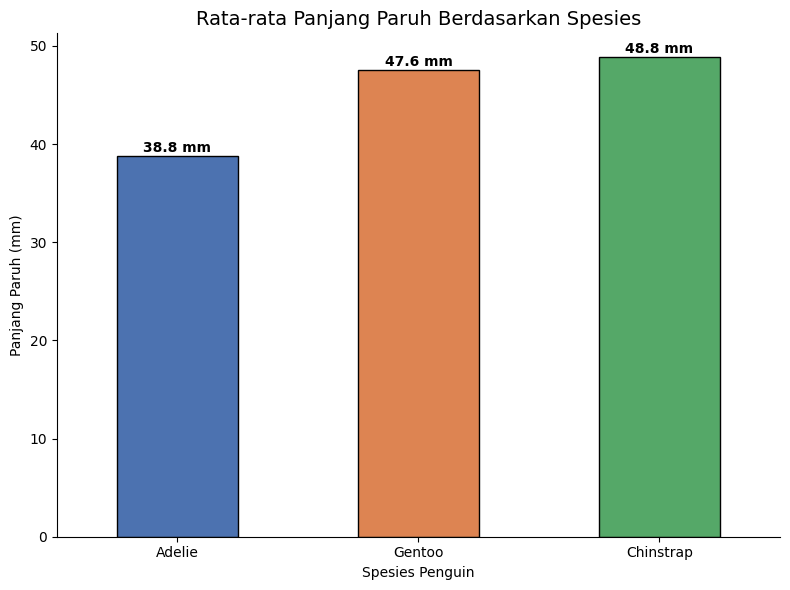

In [10]:
######################################################################
# ── VISUALISASI 1: BAR CHART ────────────────────────────────────────
#     Rata-rata panjang paruh tiap spesies
######################################################################
plt.figure(figsize=(8, 6))

mean_bill = (
    penguins_df.groupby('species')['bill_length_mm']
    .mean()
    .sort_values()
)

warna_bar = ['#4c72b0', '#dd8452', '#55a868']

mean_bill.plot(
    kind='bar',
    color=warna_bar,
    edgecolor='black'
)

plt.title('Rata-rata Panjang Paruh Berdasarkan Spesies', fontsize=14)
plt.xlabel('Spesies Penguin')
plt.ylabel('Panjang Paruh (mm)')
plt.xticks(rotation=0)

plt.gca().spines[['top', 'right']].set_visible(False)

for idx, nilai in enumerate(mean_bill.values):
    plt.text(idx, nilai + 0.4,
             f'{nilai:.1f} mm',
             ha='center',
             fontweight='bold')

plt.tight_layout()
plt.show()

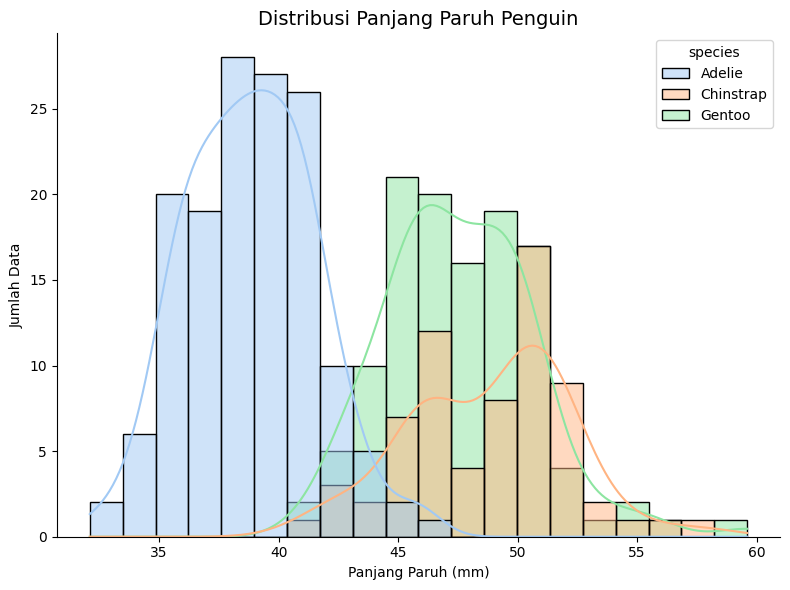

In [11]:
######################################################################
# ── VISUALISASI 2: HISTOGRAM ────────────────────────────────────────
#     Distribusi panjang paruh
######################################################################
plt.figure(figsize=(8, 6))

sns.histplot(
    data=penguins_df,
    x='bill_length_mm',
    hue='species',
    kde=True,
    bins=20,
    palette='pastel'
)

plt.title('Distribusi Panjang Paruh Penguin', fontsize=14)
plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Jumlah Data')

plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

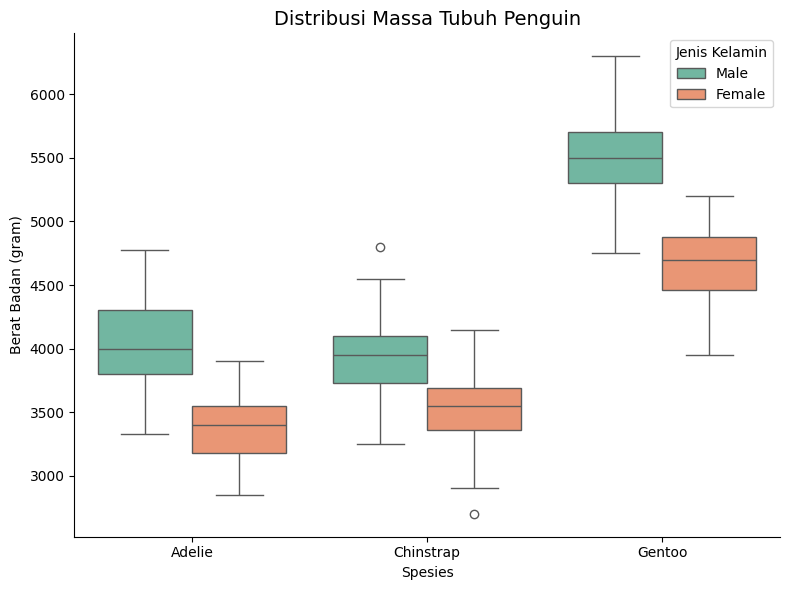

In [12]:
##############################################################################
# ── VISUALISASI 3: BOXPLOT ─────────────────────────────────────────────────
#     Massa tubuh berdasarkan spesies dan jenis kelamin
##############################################################################
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=penguins_df,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette='Set2'
)

plt.title('Distribusi Massa Tubuh Penguin', fontsize=14)
plt.xlabel('Spesies')
plt.ylabel('Berat Badan (gram)')

plt.legend(title='Jenis Kelamin')

plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

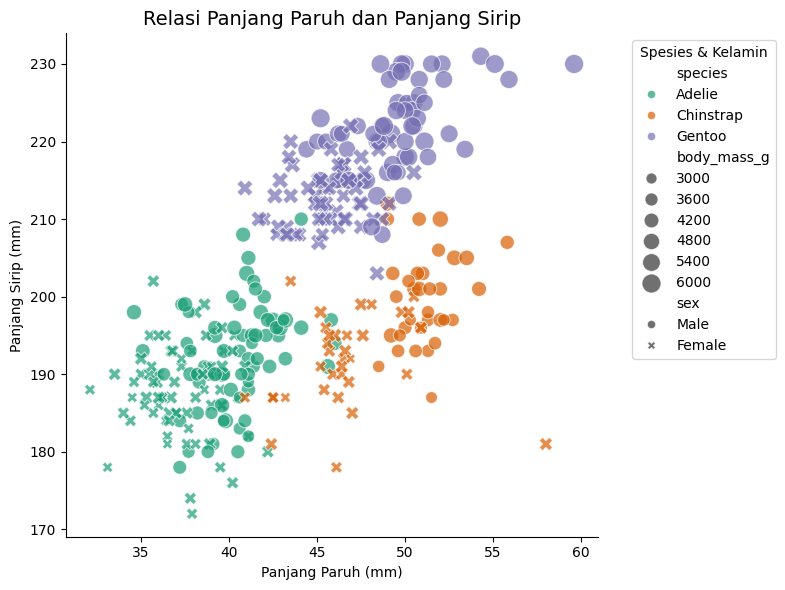

In [13]:
########################################################################
# ── VISUALISASI 4: SCATTER PLOT ──────────────────────────────────────
#     Hubungan panjang paruh dan panjang sirip
########################################################################
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=penguins_df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    style='sex',
    size='body_mass_g',
    sizes=(50, 200),
    alpha=0.7,
    palette='Dark2'
)

plt.title('Relasi Panjang Paruh dan Panjang Sirip', fontsize=14)
plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Panjang Sirip (mm)')

plt.legend(
    title='Spesies & Kelamin',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Dashboard berhasil disimpan!


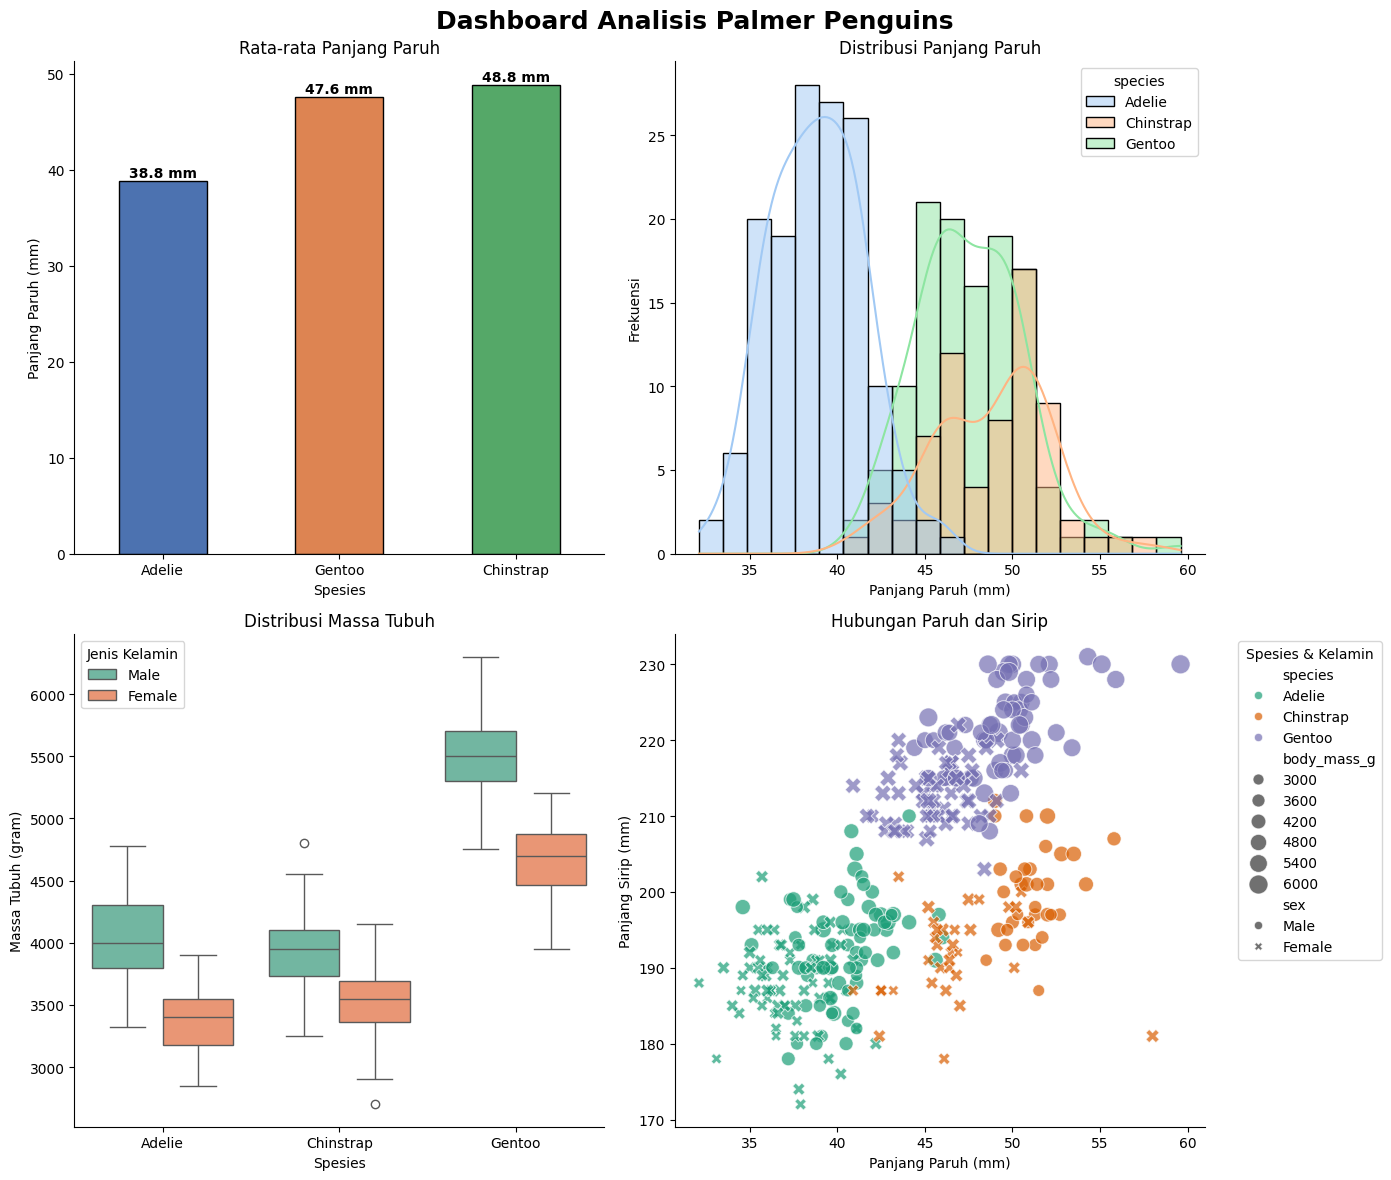

In [14]:
########################################################################
# ── MEMBUAT DASHBOARD VISUALISASI ────────────────────────────────────
########################################################################
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

fig.suptitle(
    'Dashboard Analisis Palmer Penguins',
    fontsize=18,
    fontweight='bold'
)

# ==========================================================
# Grafik 1 - Bar Chart
# ==========================================================
mean_bill.plot(
    kind='bar',
    color=warna_bar,
    edgecolor='black',
    ax=ax[0, 0]
)

ax[0, 0].set_title('Rata-rata Panjang Paruh')
ax[0, 0].set_xlabel('Spesies')
ax[0, 0].set_ylabel('Panjang Paruh (mm)')
ax[0, 0].tick_params(axis='x', rotation=0)

ax[0, 0].spines[['top', 'right']].set_visible(False)

for idx, nilai in enumerate(mean_bill.values):
    ax[0, 0].text(
        idx,
        nilai + 0.4,
        f'{nilai:.1f} mm',
        ha='center',
        fontweight='bold'
    )

# ==========================================================
# Grafik 2 - Histogram
# ==========================================================
sns.histplot(
    data=penguins_df,
    x='bill_length_mm',
    hue='species',
    kde=True,
    bins=20,
    palette='pastel',
    ax=ax[0, 1]
)

ax[0, 1].set_title('Distribusi Panjang Paruh')
ax[0, 1].set_xlabel('Panjang Paruh (mm)')
ax[0, 1].set_ylabel('Frekuensi')

ax[0, 1].spines[['top', 'right']].set_visible(False)

# ==========================================================
# Grafik 3 - Boxplot
# ==========================================================
sns.boxplot(
    data=penguins_df,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette='Set2',
    ax=ax[1, 0]
)

ax[1, 0].set_title('Distribusi Massa Tubuh')
ax[1, 0].set_xlabel('Spesies')
ax[1, 0].set_ylabel('Massa Tubuh (gram)')

ax[1, 0].legend(title='Jenis Kelamin')

ax[1, 0].spines[['top', 'right']].set_visible(False)

# ==========================================================
# Grafik 4 - Scatter Plot
# ==========================================================
sns.scatterplot(
    data=penguins_df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    style='sex',
    size='body_mass_g',
    sizes=(50, 200),
    alpha=0.7,
    palette='Dark2',
    ax=ax[1, 1]
)

ax[1, 1].set_title('Hubungan Paruh dan Sirip')
ax[1, 1].set_xlabel('Panjang Paruh (mm)')
ax[1, 1].set_ylabel('Panjang Sirip (mm)')

ax[1, 1].legend(
    title='Spesies & Kelamin',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

ax[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.savefig(
    'dashboard_penguin_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

print("Dashboard berhasil disimpan!")

plt.show()